
MC avg error : 0.00980254926893771
QAE avg error: 0.04764651275630445
QAE median error: 0.0408545392851023


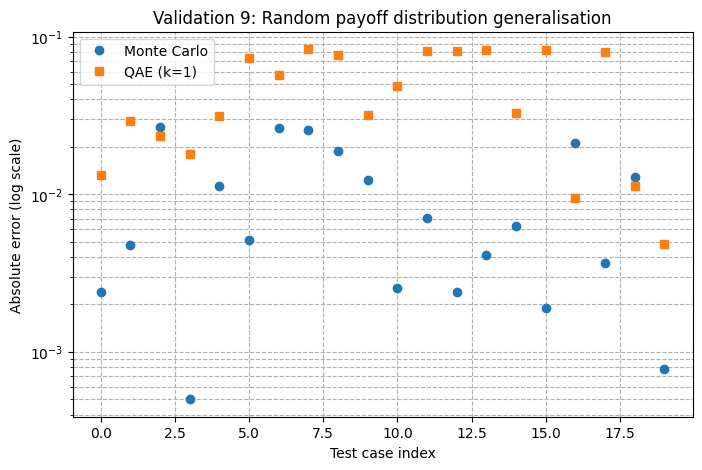

/var/folders/yn/tp4d43ns64qb0vr9l2b390ym0000gn/T/ipykernel_11567/543940959.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mc_errors, qae_errors], labels=["MC", "QAE"])


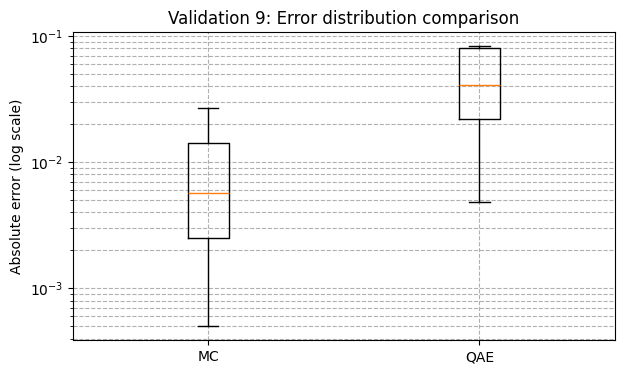

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit          # ← add this
from qiskit_aer.primitives import Sampler
sampler = Sampler()

# ----------------------------------------------------------
# Helper: single-qubit QAE as before
# ----------------------------------------------------------

def build_single_qubit_QAE(p_true):
    theta_p = 2 * math.asin(math.sqrt(p_true))
    A = QuantumCircuit(1)
    A.ry(theta_p, 0)

    Q = QuantumCircuit(1)
    Q.ry(theta_p, 0)
    Q.z(0)
    Q.ry(-theta_p, 0)
    Q.x(0); Q.z(0); Q.x(0)

    return A, Q

def qae_invert(p_true, k, p_k):
    if k == 0:
        return p_k
    p_k = max(0,min(1,p_k))
    alpha = math.asin(math.sqrt(p_k))
    theta1 = alpha/(2*k+1)
    theta2 = (math.pi - alpha)/(2*k+1)
    p1, p2 = math.sin(theta1)**2, math.sin(theta2)**2
    return p1 if abs(p1-p_true)<abs(p2-p_true) else p2

def run_qae_single(p_true, k, shots=4000):
    A, Q = build_single_qubit_QAE(p_true)
    qc = QuantumCircuit(1,1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0,0)

    result = sampler.run([qc], shots=shots).result()
    dist = result.quasi_dists[0]
    p_k = dist.get(1, 0)
    p_hat = qae_invert(p_true, k, p_k)
    return p_hat


# ----------------------------------------------------------
# Validation 9: Random payoff distribution generalisation
# ----------------------------------------------------------

np.random.seed(42)

num_payoffs = 20
dimension   = 8                # number of discrete payoff values
C_scale     = 30               # ensures stable amplitudes

mc_N        = 30000            # MC samples
shots_qae   = 5000
k_qae       = 1                # stable fixed-k method from earlier

mc_errors   = []
qae_errors  = []

for _ in range(num_payoffs):

    # Random discrete support
    values = np.random.uniform(0, 10, size=dimension)
    probs  = np.random.dirichlet(np.ones(dimension))

    # True expectation
    E_true = np.sum(values * probs)

    # Amplitude scaling
    p_true = E_true / C_scale
    if p_true > 0.45:
        # rescale automatically to remain in stable region
        C_scale = 2 * E_true / 0.3
        p_true = E_true / C_scale

    # Monte Carlo baseline
    mc_samples = np.random.choice(values, size=mc_N, p=probs)
    mc_est = mc_samples.mean()
    mc_errors.append(abs(mc_est - E_true))

    # QAE estimator on amplitude domain
    p_est = run_qae_single(p_true, k_qae, shots=shots_qae)
    qae_est = C_scale * p_est
    qae_errors.append(abs(qae_est - E_true))


mc_errors  = np.array(mc_errors)
qae_errors = np.array(qae_errors)

print("\nMC avg error :", mc_errors.mean())
print("QAE avg error:", qae_errors.mean())
print("QAE median error:", np.median(qae_errors))


# ----------------------------------------------------------
# Plot comparison
# ----------------------------------------------------------

plt.figure(figsize=(8,5))
plt.yscale("log")
plt.plot(mc_errors,  'o', label="Monte Carlo")
plt.plot(qae_errors, 's', label=f"QAE (k={k_qae})")
plt.title("Validation 9: Random payoff distribution generalisation")
plt.xlabel("Test case index")
plt.ylabel("Absolute error (log scale)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


# Boxplot summary
plt.figure(figsize=(7,4))
plt.yscale("log")
plt.boxplot([mc_errors, qae_errors], labels=["MC", "QAE"])
plt.title("Validation 9: Error distribution comparison")
plt.ylabel("Absolute error (log scale)")
plt.grid(True, which="both", ls="--")
plt.show()
